## Imports and result directories


In [1]:
from base64 import b64encode
from io import BytesIO
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

ROOT = next(
    (
        parent
        for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (parent / "examples" / "gaussian").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Run this notebook from the repository root or a directory within it.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from examples.gaussian.analysis.plot import load_runs, plot_metric_grid

GAUSSIAN_RESULT_DIR = ROOT / "examples" / "gaussian" / "results"
RESULT_DIRS = {
    "default": GAUSSIAN_RESULT_DIR,
    "seed_2026": GAUSSIAN_RESULT_DIR / "ablation" / "seed_2026",
    "fixed_lr": GAUSSIAN_RESULT_DIR / "ablation" / "fixed_lr",
    "no_standardize": GAUSSIAN_RESULT_DIR / "ablation" / "no_standardize",
}
SETTING_LABELS = {
    "default": "Default",
    "seed_2026": "Different seed",
    "fixed_lr": "Fixed learning rate",
    "no_standardize": "No standardization",
}
SUMMARY_DIMS = (40, 80)
RUN_LABELS = {40: "S=2D", 80: "S=4D"}
KEYS = ["source_model", "id", "candidate_model"]


## Load and check paired saved runs


In [2]:
all_runs = {
    setting: load_runs(
        method="indirect",
        num_obs=10,
        summary_dims=list(SUMMARY_DIMS),
        result_dir=result_dir,
    )
    for setting, result_dir in RESULT_DIRS.items()
}
for setting, runs in all_runs.items():
    if set(runs) != set(RUN_LABELS.values()):
        raise ValueError(f"{setting}: expected only S=2D and S=4D, got {list(runs)}")

for dim, run_label in RUN_LABELS.items():
    baseline = all_runs["default"][run_label].set_index(KEYS).sort_index()
    for setting in RESULT_DIRS:
        aligned = all_runs[setting][run_label].set_index(KEYS).sort_index()
        if not aligned.index.equals(baseline.index):
            raise ValueError(f"{setting}, S={dim}: dataset/model rows differ from Default")
        for column in ("gold_logml", "gold_pmp"):
            if column not in baseline or column not in aligned:
                raise ValueError(f"{setting}, S={dim}: missing {column}")
            try:
                pd.testing.assert_series_equal(baseline[column], aligned[column], check_exact=True)
            except AssertionError as exc:
                raise ValueError(f"{setting}, S={dim}: {column} differs from Default") from exc

print("All paired dataset keys and shared gold standards match for S=40 and S=80.")


All paired dataset keys and shared gold standards match for S=40 and S=80.


In [3]:
RENDER_DPI = 120
_png_cache = {}

def _keep_l2_density(fig, axes):
    # plot_metric_grid creates 16 data axes, four column strips, then four row strips.
    if axes.shape != (4, 4) or len(fig.axes) != 24:
        raise ValueError("Unexpected plot_metric_grid layout; check plot.py before adapting it")
    column_strips = fig.axes[16:20]
    row_strips = fig.axes[20:24]
    positions = ((0, 0.105), (2, 0.505))
    panel_width = 0.36

    for column in (1, 3):
        for ax in axes[:, column]:
            ax.remove()
        column_strips[column].remove()

    for column, x0 in positions:
        for ax in axes[:, column]:
            bounds = ax.get_position()
            ax.set_position([x0, bounds.y0, panel_width, bounds.height])
        strip = column_strips[column]
        bounds = strip.get_position()
        strip.set_position([x0, bounds.y0, panel_width, bounds.height])

    for strip in row_strips:
        bounds = strip.get_position()
        strip.set_position([0.885, bounds.y0, 0.07, bounds.height])
    fig.set_size_inches(14, 20, forward=True)

def _plot_png(setting, metric):
    key = (setting, metric)
    if key not in _png_cache:
        options = {"ylim": (-1.05, 1.05)} if metric == "pmp" else {}
        fig, axes = plot_metric_grid(all_runs[setting], metric=metric, **options)
        try:
            _keep_l2_density(fig, axes)
            buffer = BytesIO()
            fig.savefig(buffer, format="png", dpi=RENDER_DPI, bbox_inches="tight")
            _png_cache[key] = b64encode(buffer.getvalue()).decode("ascii")
        finally:
            plt.close(fig)
    return _png_cache[key]

def show_pair(setting, metric):
    if setting not in RESULT_DIRS or setting == "default":
        raise ValueError("Choose seed_2026, fixed_lr, or no_standardize")
    if metric not in ("posterior_mmd", "logml", "pmp"):
        raise ValueError("Choose posterior_mmd, logml, or pmp")
    left = _plot_png("default", metric)
    right = _plot_png(setting, metric)
    label = SETTING_LABELS[setting]
    display(HTML(
        f'<div style="display:flex; gap:10px; width:100%; max-width:100%; align-items:flex-start;">'
        f'<div style="flex:1 1 0; min-width:0;">'
        f'<h4>Default</h4><img alt="Default {metric}: L2 and Density" '
        f'src="data:image/png;base64,{left}" style="display:block; width:100%; height:auto;"></div>'
        f'<div style="flex:1 1 0; min-width:0;">'
        f'<h4>{label}</h4><img alt="{label} {metric}: L2 and Density" '
        f'src="data:image/png;base64,{right}" style="display:block; width:100%; height:auto;"></div>'
        f'</div>'
    ))


## Posterior MMD


### Default vs Different seed


Default Different seed
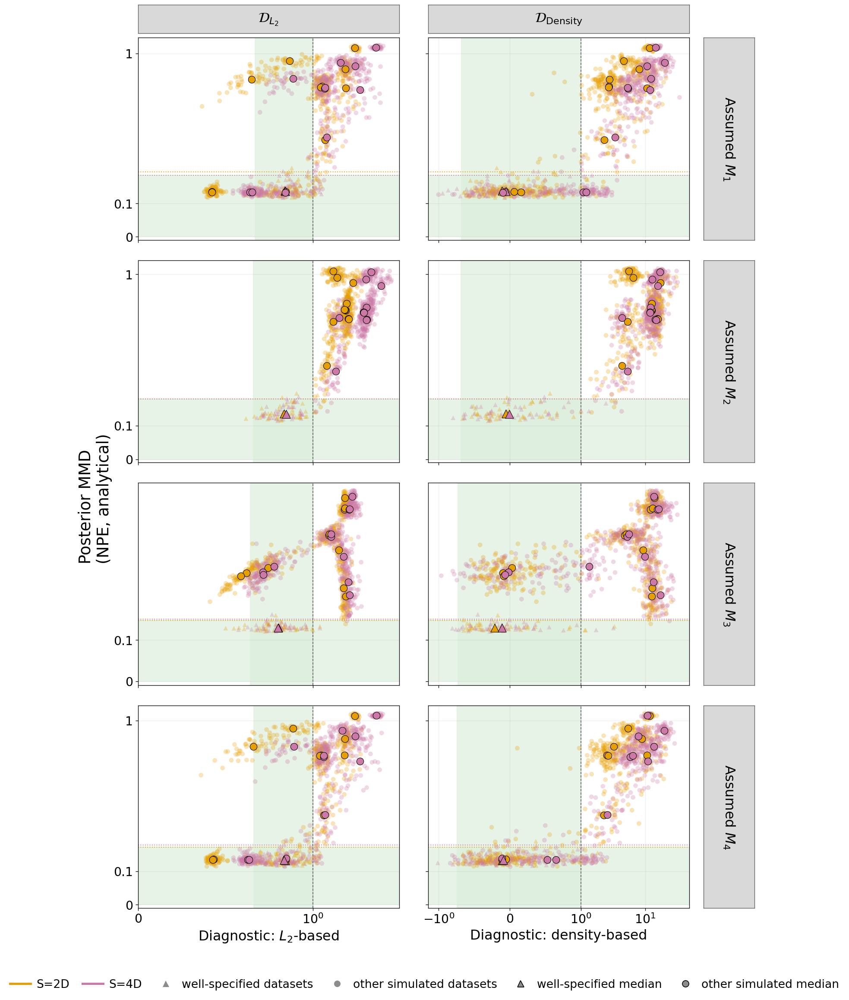
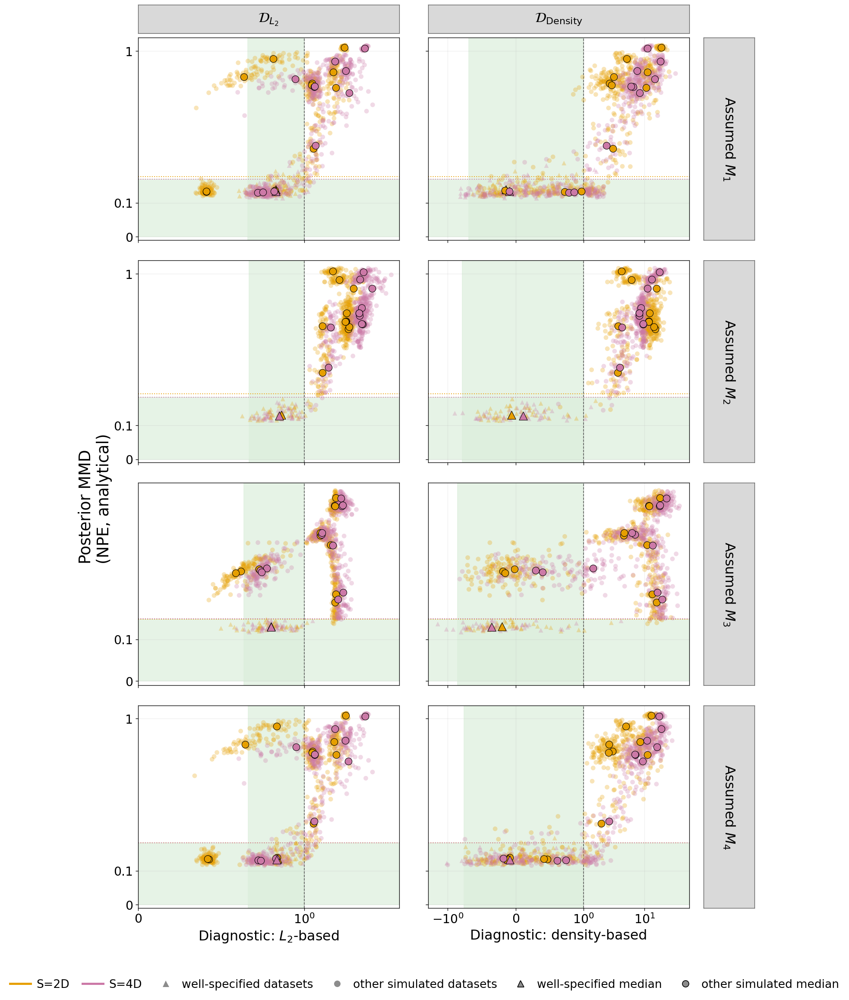

In [4]:
show_pair("seed_2026", "posterior_mmd")


### Default vs Fixed learning rate


Default Fixed learning rate
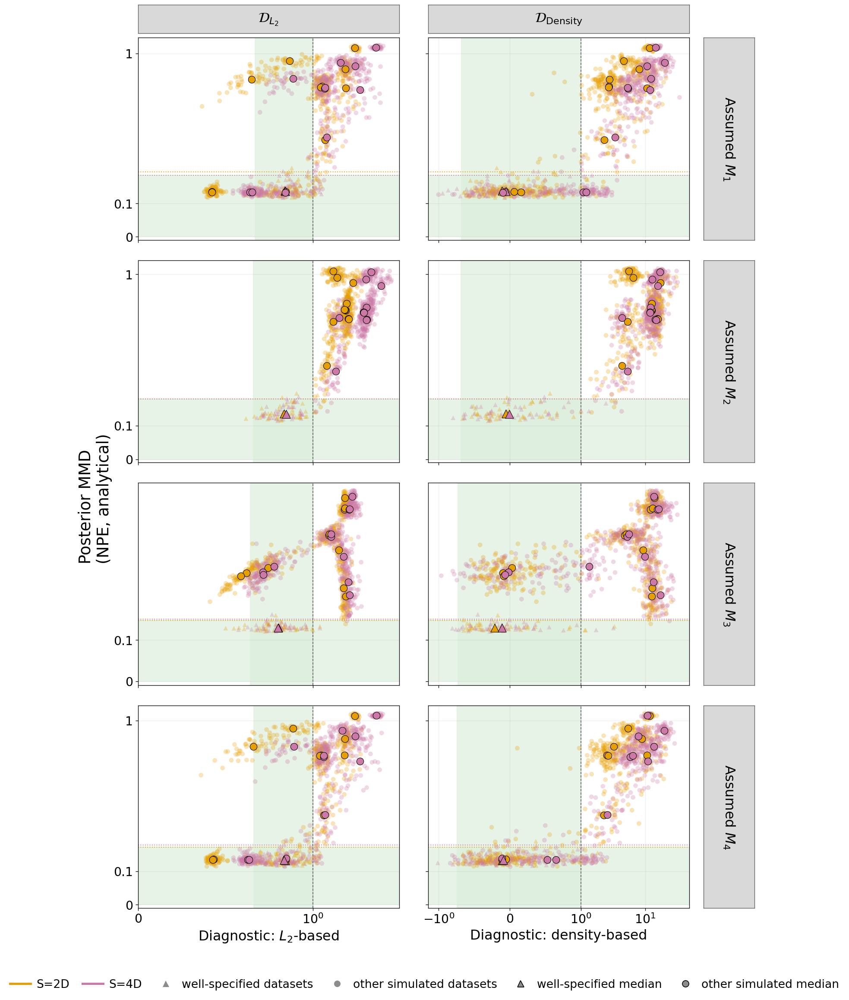
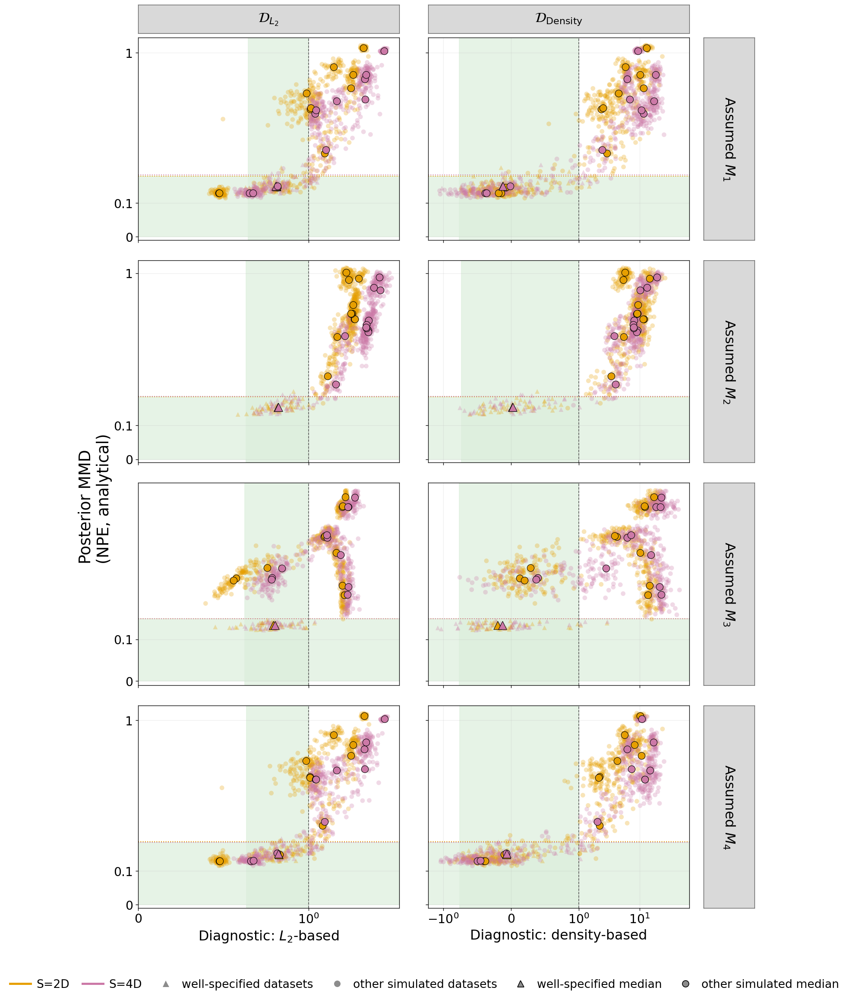

In [5]:
show_pair("fixed_lr", "posterior_mmd")


### Default vs No standardization


Default No standardization
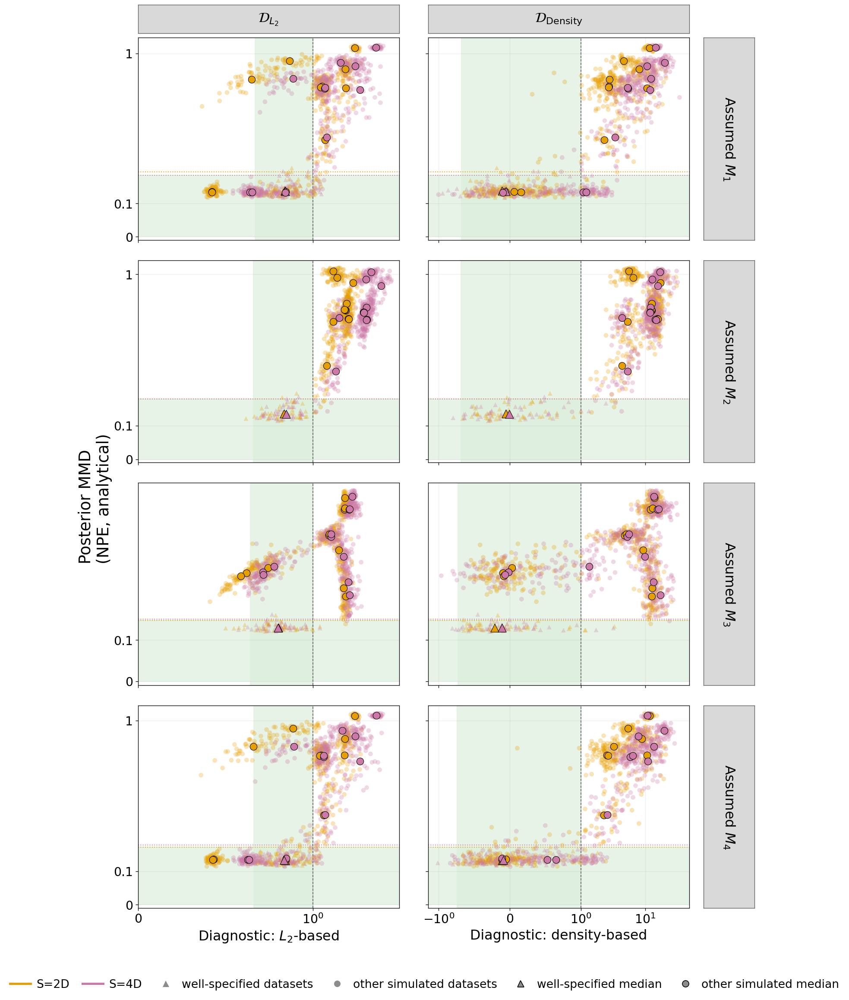
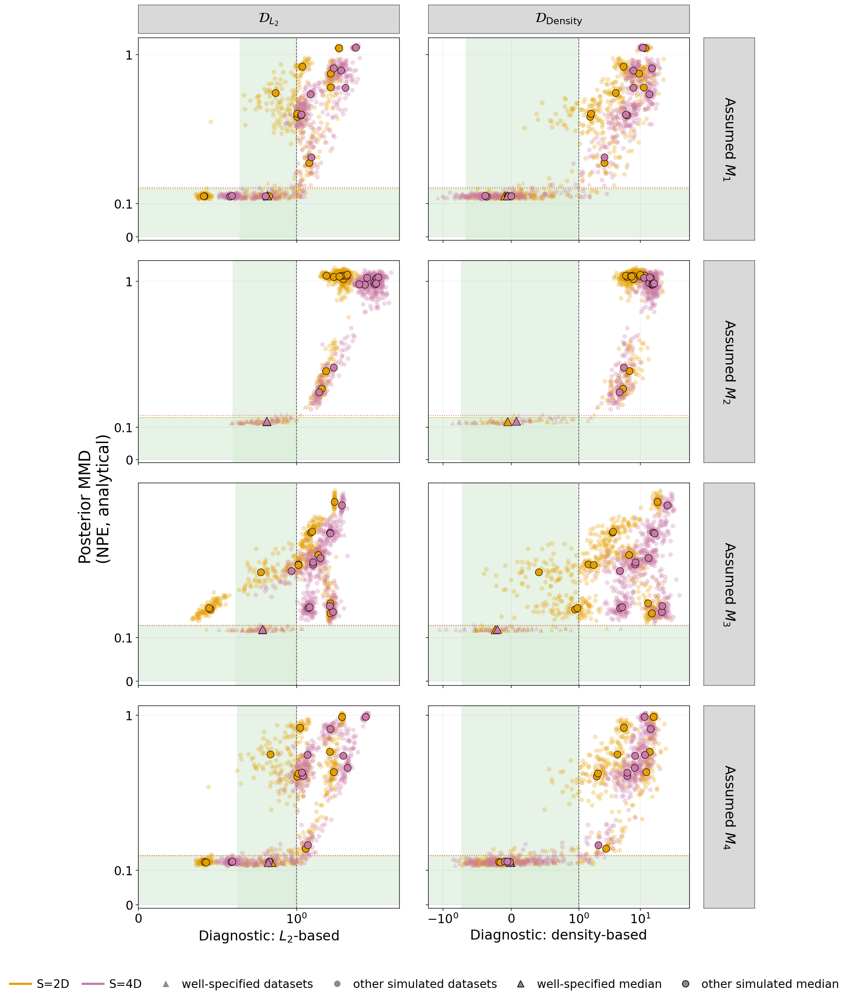

In [6]:
show_pair("no_standardize", "posterior_mmd")


## Log10 marginal-likelihood error


### Default vs Different seed


Default Different seed
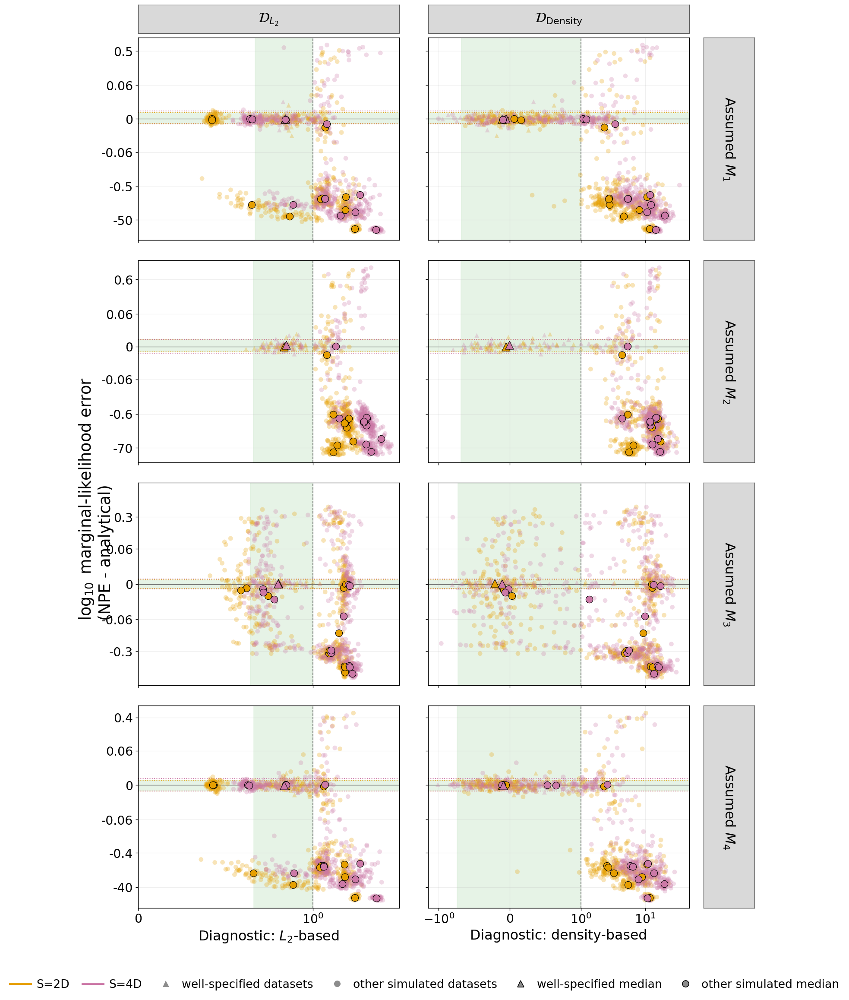
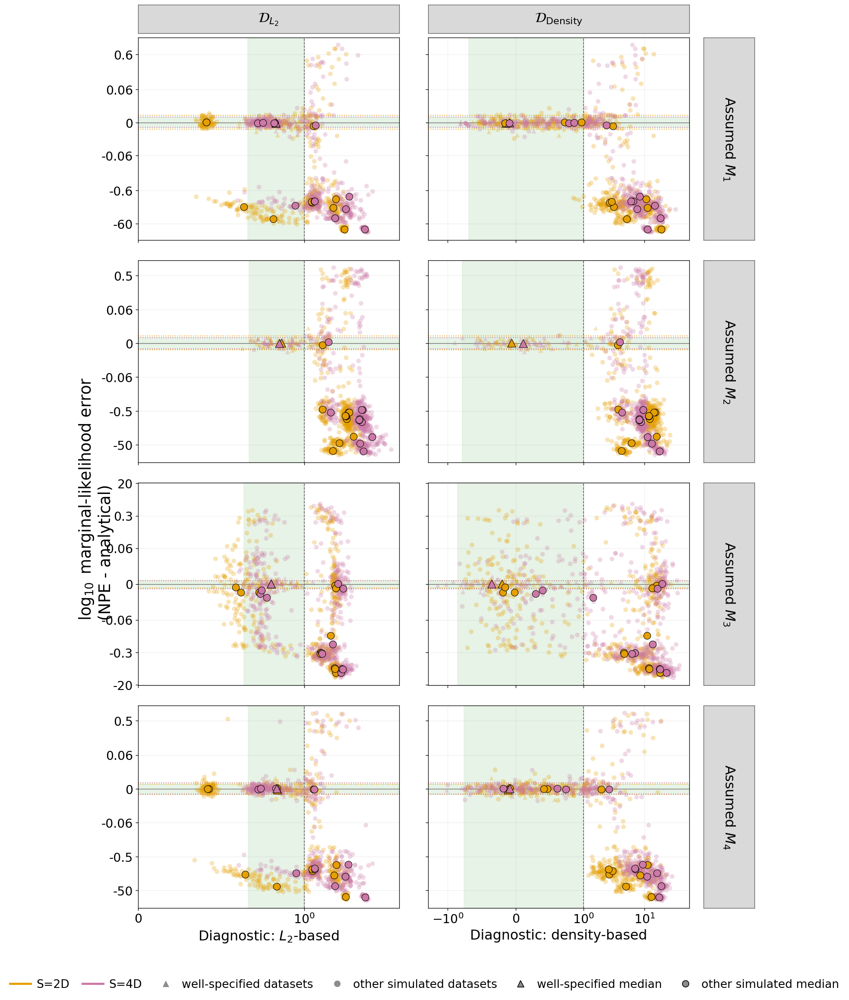

In [7]:
show_pair("seed_2026", "logml")


### Default vs Fixed learning rate


Default Fixed learning rate
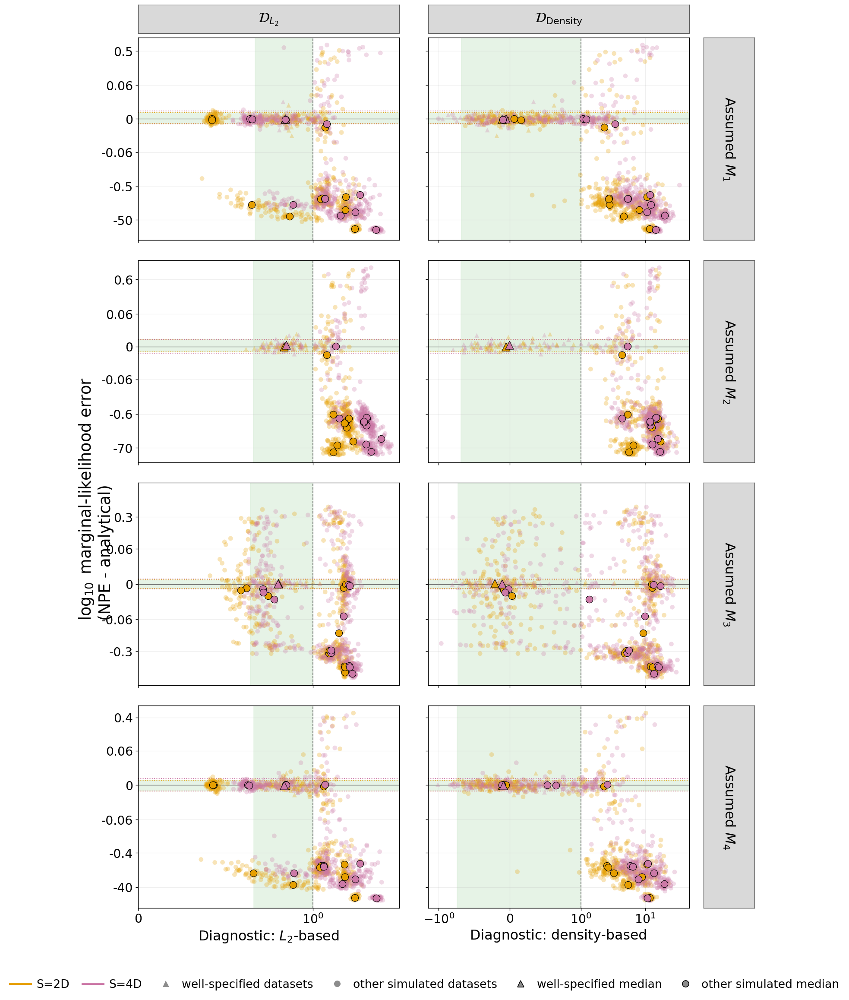
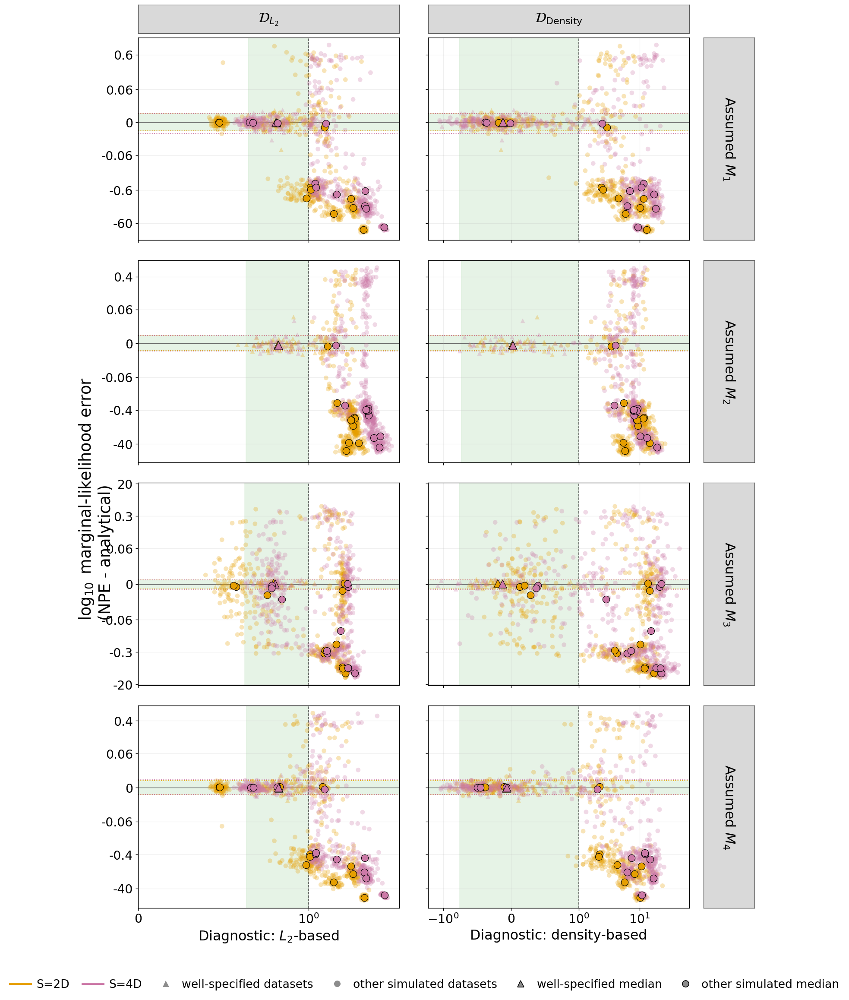

In [8]:
show_pair("fixed_lr", "logml")


### Default vs No standardization


Default No standardization
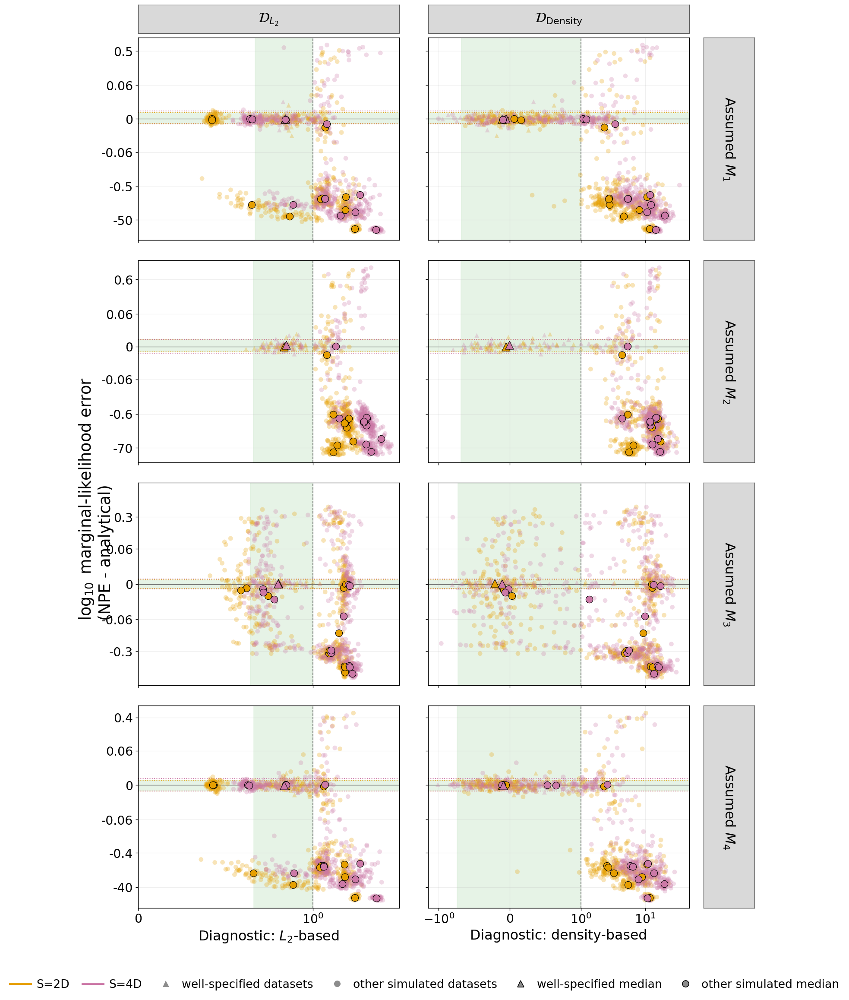
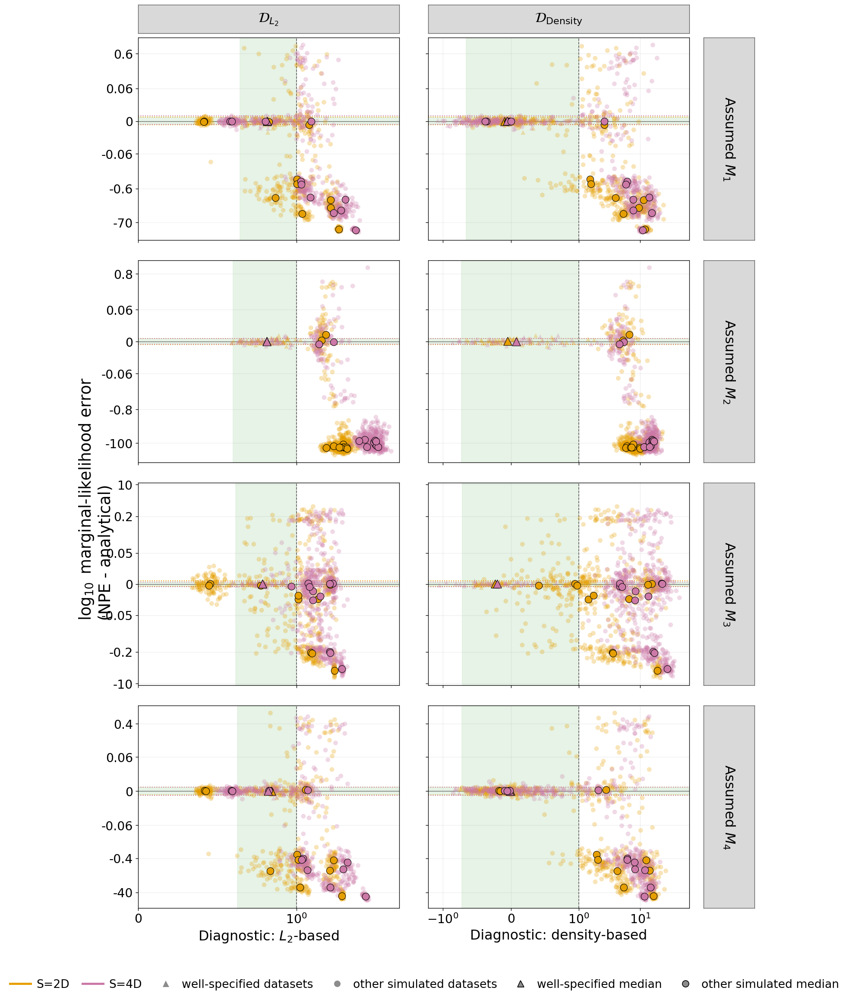

In [9]:
show_pair("no_standardize", "logml")


## PMP error


### Default vs Different seed


Default Different seed
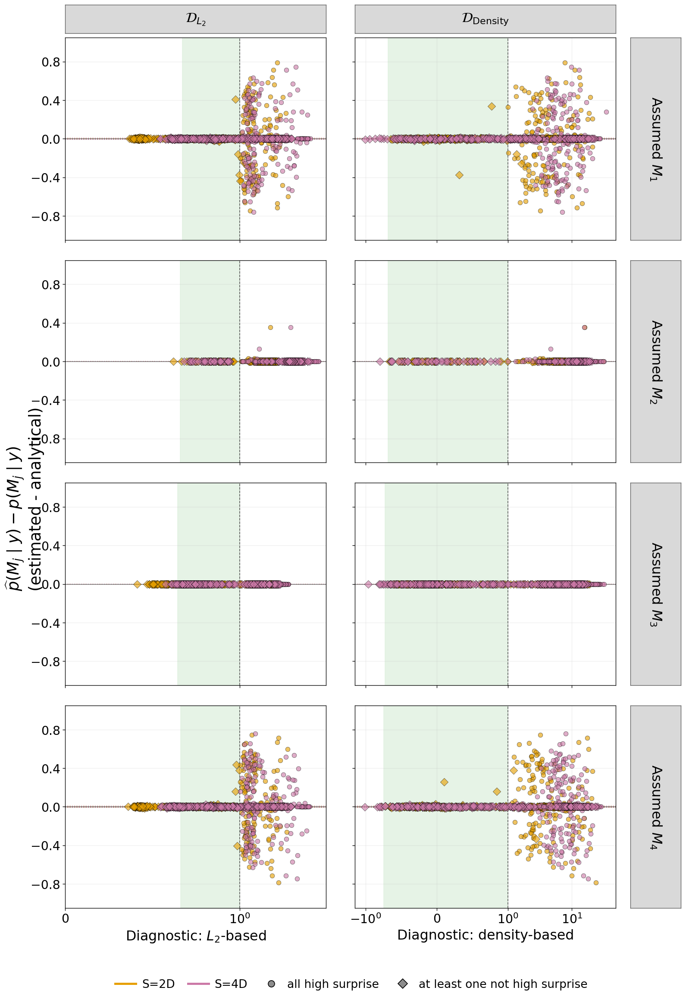
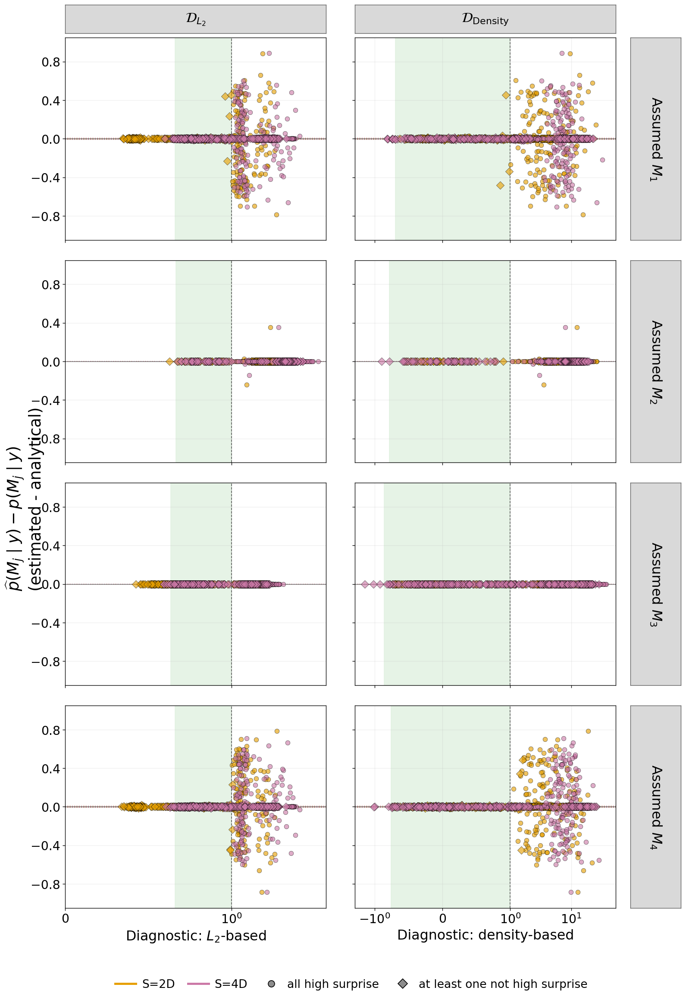

In [10]:
show_pair("seed_2026", "pmp")


### Default vs Fixed learning rate


Default Fixed learning rate
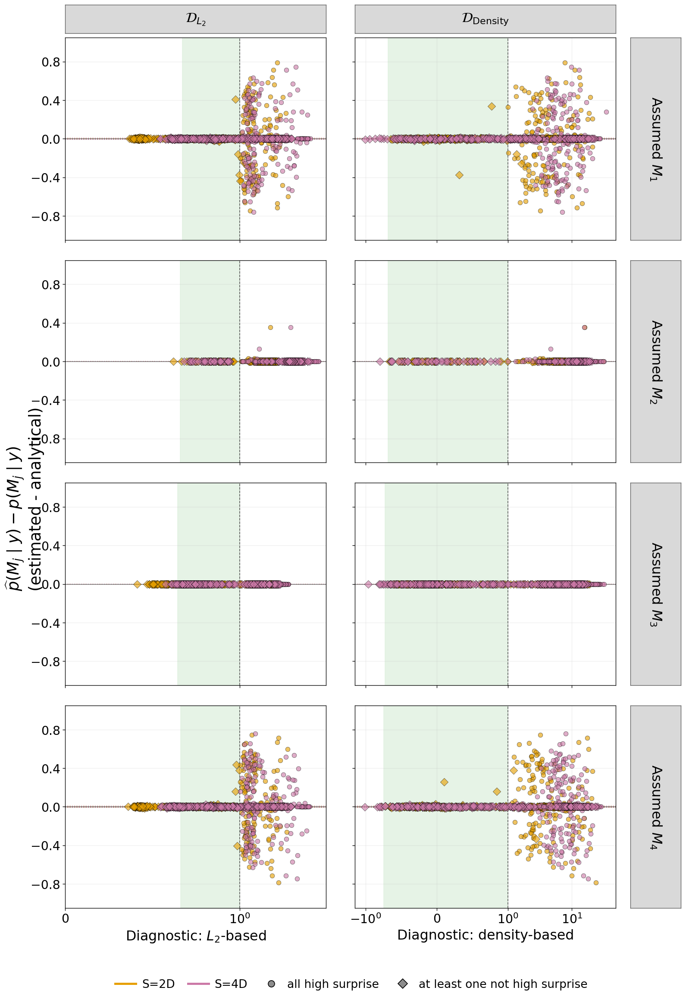
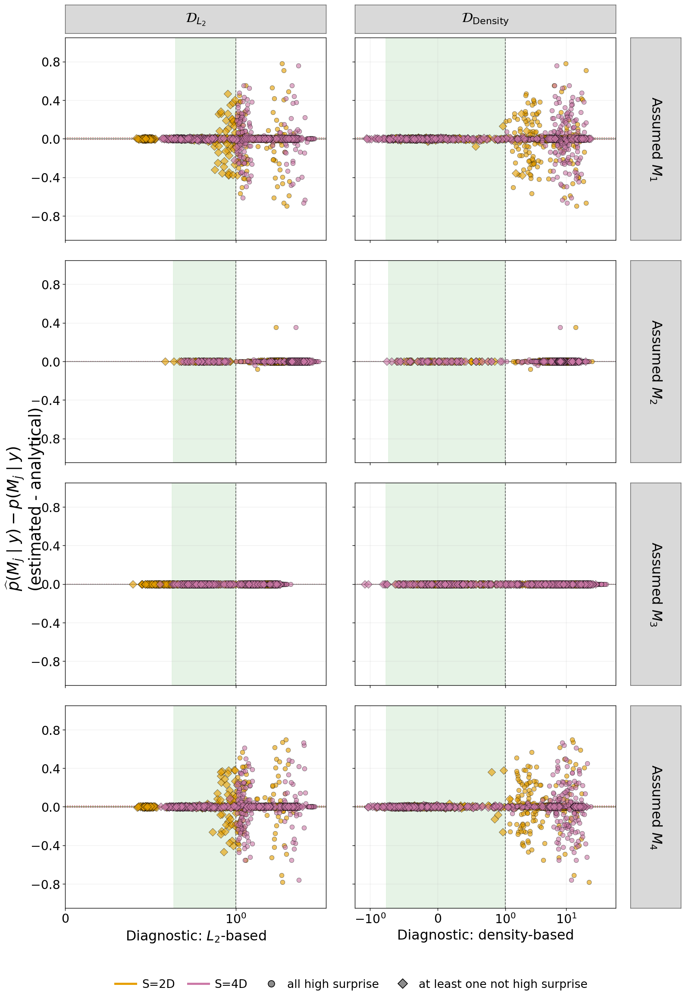

In [11]:
show_pair("fixed_lr", "pmp")


### Default vs No standardization


Default No standardization
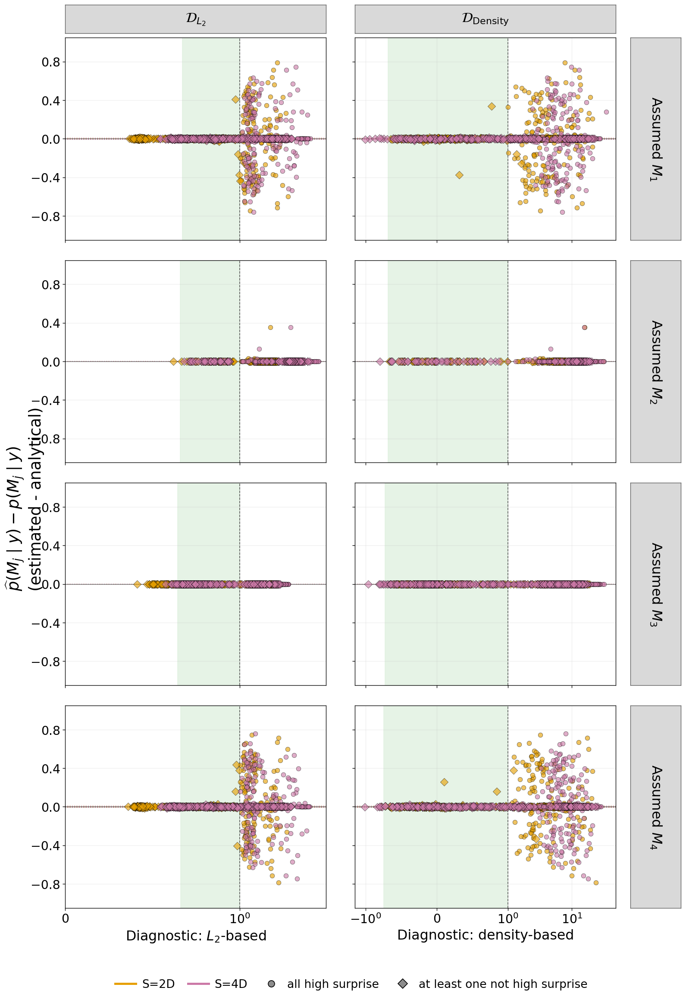
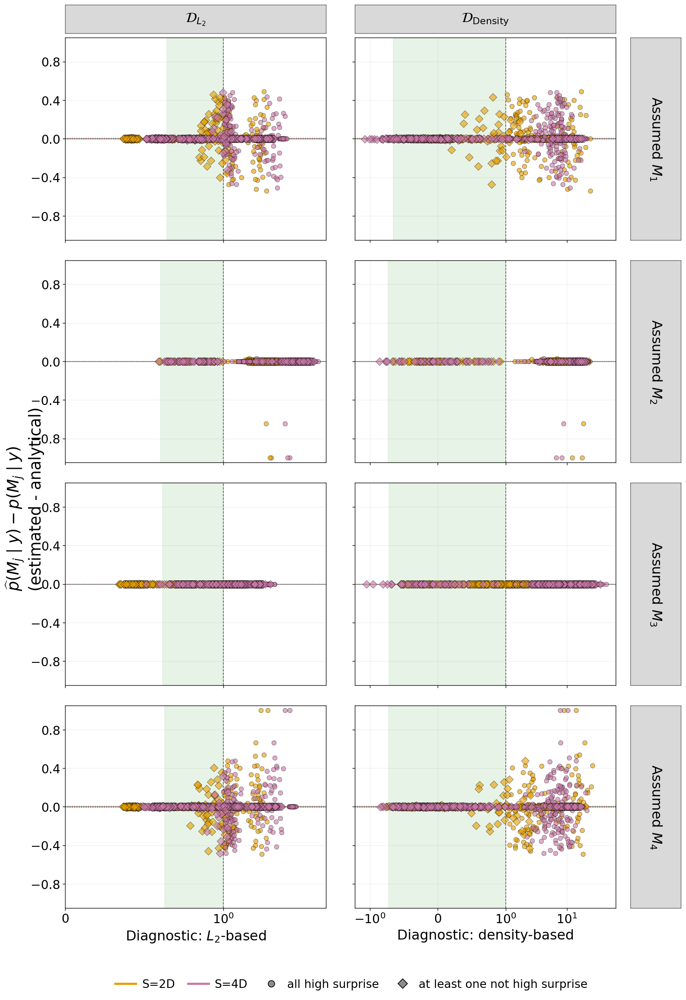

In [12]:
show_pair("no_standardize", "pmp")
